# Substrate integrated waveguide filter with CSRRs
<center><img src="./img/siw_csrr_stackup_3d.png" width=720 /></center>
An SIW is a rectangular waveguide built inside a PCB: two rows of plated through-vias
replace the side walls, so the whole structure comes out of a standard etch-and-drill
process. Etching a complementary split-ring resonator (CSRR) into the broadwall places
a sharp transmission zero just above the SIW TE₁₀ cutoff; cascading CSRRs of slightly
different sizes spreads those zeros and shapes a compact band-pass response. This notebook
reproduces the three-cell filter of Zhang, Yu & Xu [1].


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.rf as rf
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tidy3d import web
from tidy3d.plugins.dispersion import FastDispersionFitter

td.config.logging.level = "ERROR"

## Parameters

Lengths in μm (Tidy3D default), frequencies in Hz. Axis convention used throughout:

| Axis | Role        | Description                                              |
| ---- | ----------- | -------------------------------------------------------- |
| x    | propagation | along the feed lines; ports at the ±x extents            |
| y    | transverse  | across the SIW width; via rows at y = ±a/2               |
| z    | stack-up    | substrate thickness; top metal above, bottom ground below |


In [2]:
# Frequency sweep and field-monitor sampling
f_min = 2e9  # Hz, lower sweep edge
f_max = 12e9  # Hz, upper sweep edge (above the last CSRR zero)
n_freqs = 201  # sweep points
n_field_freqs = 201  # field-monitor frequencies

freqs = np.linspace(f_min, f_max, n_freqs)
field_freqs = np.linspace(f_min, f_max, n_field_freqs)

### Substrate and Metal Properties

The stack is RT/Duroid 5880 sandwiched between two copper layers.

In [3]:
# Substrate (RT/Duroid 5880, paper Section 3)
eps_sub = 2.22  # relative permittivity
losstan_sub = 0.002  # loss tangent
h_sub = 254  # μm, substrate thickness

# Metal (copper, 1 oz PCB)
cond_metal = 58  # S/μm (5.8e7 S/m)
t_metal = 17  # μm

### SIW, Plate, and Feed Dimensions

<img src="./img/siw_csrr_layout_2d.png" width="920">

*Top view — SIW broadwall plate (gold) between two via rows, tapered to microstrip feeds
at each end. The three CSRRs sit on the SIW centerline.*

In [4]:
# SIW via fence
a_siw = 14000  # μm, via-row separation (y)
via_d = 800  # μm, via diameter
via_pitch = 1600  # μm, via spacing along x

# Plate (top-metal broadwall) geometry
plate_margin_y = (
    960  # μm, plate extension past each via row in y (paper doesn't specify; ≈ 1 mm fits the photo)
)
cell_pitch_x = 6000  # μm, center-to-center CSRR spacing
end_margin_x = 2600  # μm, end-CSRR center to nearest plate edge
L_plate_x = 2 * end_margin_x + 2 * cell_pitch_x  # μm, total plate length in x (17.2 mm)
plate_half_y = a_siw / 2 + plate_margin_y  # μm, half plate width in y (7.96 mm)

# Feed + taper
w_ms = 760  # μm, microstrip line width (50 Ω on this substrate)
L_taper = 5500  # μm, taper length (pointy tip → plate edge)
w_taper_mouth = 1720  # μm, taper mouth width at the plate edge

# Asymmetric microstrip feeds (input shorter than output).
L_ms_L = 5500  # μm, left (input) microstrip length
L_ms_R = 11500  # μm, right (output) microstrip length

# Top-metal x-coordinates (plate centered on x=0; feeds are asymmetric).
x_plate_L = -L_plate_x / 2
x_plate_R = +L_plate_x / 2
x_taper_tip_L = x_plate_L - L_taper
x_taper_tip_R = x_plate_R + L_taper
x_ms_L = x_taper_tip_L - L_ms_L
x_ms_R = x_taper_tip_R + L_ms_R

# Finite PCB footprint — substrate + ground match the top-metal extent in y.
sub_x_center = (x_ms_L + x_ms_R) / 2
sub_x_len = x_ms_R - x_ms_L
sub_y_len = 2 * plate_half_y

### CSRR Cell Dimensions

<img src="./img/siw_csrr_cell.png" width="380">

*Schematic of the CSRR: `f`, `s`, `g` are fixed and shared across all
three CSRRs; here the transmission-zero frequency is tuned by changing `c, d`.*

In [5]:
# CSRR geometry (shared across all three cells):
#   f = slot arm width (air-channel thickness of each ring)
#   s = inter-ring metal gap (metal strip between outer and inner slots)
#   g = break width (metal bridge in each ring; same value for both)
# Per-cell c, d tune each transmission zero.
csrr_f = 300  # μm, slot arm width
csrr_s = 200  # μm, inter-ring metal gap
csrr_g = 400  # μm, break width (outer and inner)

# Per-cell outer-ring dimensions (paper's CSRR2, CSRR1, CSRR3 = left, mid, right)
csrr_c_left = 3700  # μm, outer height (along y)
csrr_d_left = 1850  # μm, outer width (along x)
csrr_c_mid = 4000  # μm, outer height (along y)
csrr_d_mid = 2000  # μm, outer width (along x)
csrr_c_right = 3800  # μm, outer height (along y)
csrr_d_right = 1900  # μm, outer width (along x)

## Media

We model RT/Duroid 5880 substrate with a frequency-dependent loss tangent, and copper traces as a finite-conductivity metal.


In [6]:
med_sub = FastDispersionFitter.constant_loss_tangent_model(
    eps_sub, losstan_sub, (f_min, f_max), tolerance_rms=3e-4
)
med_metal = rf.LossyMetalMedium(
    conductivity=cond_metal, frequency_range=(f_min, f_max), name="Lossy Copper"
)
med_air = td.Medium(permittivity=1.0, name="Air")

Output()

## Geometry

### Substrate and Bottom Ground


In [7]:
# substrate box
str_sub = td.Structure(
    geometry=td.Box(
        center=(sub_x_center, 0, -h_sub / 2),
        size=(sub_x_len, sub_y_len, h_sub),
    ),
    medium=med_sub,
)

# ground plate
str_gnd = td.Structure(
    geometry=td.Box(
        center=(sub_x_center, 0, -h_sub - t_metal / 2),
        size=(sub_x_len, sub_y_len, t_metal),
    ),
    medium=med_metal,
)

### CSRR Slot Structures


In [8]:
def csrr_slot_boxes(x_c, y_c, c, d, f, s, g, z_mid):
    """Decompose the two slot frames of a CSRR into axis-aligned ``td.Box`` primitives.

    Ring geometry:
    - f: slot arm width (air-channel thickness of each ring)
    - s: inter-ring metal gap (metal strip between outer and inner slot)
    - g: break width (metal bridge in each ring; same value for both)

    Orientation in this filter:
    - Outer ring (d × c): break of y-extent ``g`` on the -x (left) arm.
    - Inner ring ((d - 2(f+s)) × (c - 2(f+s))): break of y-extent ``g`` on the +x (right) arm.

    Box z-size = t_metal so the air override acts only on the top plate.
    """
    boxes = []
    rings = [
        (d, c, -1),  # outer: break on -x
        (d - 2 * (f + s), c - 2 * (f + s), +1),  # inner: break on +x
    ]
    for W, H, break_side in rings:
        arm_len = H - 2 * f  # vertical side-arm extent (corners belong to top/bottom)
        # Top and bottom horizontal arms (full width; include corners).
        boxes.append(td.Box(center=(x_c, y_c + (H - f) / 2, z_mid), size=(W, f, t_metal)))
        boxes.append(td.Box(center=(x_c, y_c - (H - f) / 2, z_mid), size=(W, f, t_metal)))
        # Left and right vertical arms.
        for side in (-1, +1):
            x_arm = x_c + side * (W - f) / 2
            if side == break_side:
                half_len = (arm_len - g) / 2
                y_off = (arm_len + g) / 4
                boxes.append(
                    td.Box(center=(x_arm, y_c + y_off, z_mid), size=(f, half_len, t_metal))
                )
                boxes.append(
                    td.Box(center=(x_arm, y_c - y_off, z_mid), size=(f, half_len, t_metal))
                )
            else:
                boxes.append(td.Box(center=(x_arm, y_c, z_mid), size=(f, arm_len, t_metal)))
    return boxes

In [9]:
# Three CSRRs along x, centered on y=0 (the SIW midline).
# Absolute x centers: -6 mm, 0, +6 mm (plate is centered on x=0).
z_top_mid = t_metal / 2

csrr_specs = [
    # (x_center,        y_c, c,              d,              label)
    (-cell_pitch_x, 0.0, csrr_c_left, csrr_d_left, "left (CSRR2)"),
    (0.0, 0.0, csrr_c_mid, csrr_d_mid, "mid  (CSRR1)"),
    (+cell_pitch_x, 0.0, csrr_c_right, csrr_d_right, "right (CSRR3)"),
]

# Union of all slot boxes; subtracted from the top plate below.
csrr_slot_geom = sum(
    box
    for (xc, yc, c, d, _) in csrr_specs
    for box in csrr_slot_boxes(xc, yc, c, d, csrr_f, csrr_s, csrr_g, z_top_mid)
)

### Top-Metal Structures


In [10]:
# SIW broadwall plate with the three CSRRs cut out via boolean subtraction.
plate_box = td.Box(
    center=(0, 0, t_metal / 2),
    size=(L_plate_x, 2 * plate_half_y, t_metal),
)
str_plate = td.Structure(
    geometry=plate_box - csrr_slot_geom,
    medium=med_metal,
)

# Microstrip feed lines — one Box on each side, using the asymmetric feed lengths.
str_ms_L = td.Structure(
    geometry=td.Box(
        center=((x_ms_L + x_taper_tip_L) / 2, 0, t_metal / 2),
        size=(L_ms_L, w_ms, t_metal),
    ),
    medium=med_metal,
)
str_ms_R = td.Structure(
    geometry=td.Box(
        center=((x_ms_R + x_taper_tip_R) / 2, 0, t_metal / 2),
        size=(L_ms_R, w_ms, t_metal),
    ),
    medium=med_metal,
)

# Tapers — trapezoidal PolySlabs widening from w_ms at the tip to w_taper_mouth at the plate edge.
# Vertices in counter-clockwise order.
str_taper_L = td.Structure(
    geometry=td.PolySlab(
        vertices=[
            (x_taper_tip_L, -w_ms / 2),
            (x_plate_L, -w_taper_mouth / 2),
            (x_plate_L, +w_taper_mouth / 2),
            (x_taper_tip_L, +w_ms / 2),
        ],
        axis=2,
        slab_bounds=(0, t_metal),
    ),
    medium=med_metal,
)
str_taper_R = td.Structure(
    geometry=td.PolySlab(
        vertices=[
            (x_plate_R, -w_taper_mouth / 2),
            (x_taper_tip_R, -w_ms / 2),
            (x_taper_tip_R, +w_ms / 2),
            (x_plate_R, +w_taper_mouth / 2),
        ],
        axis=2,
        slab_bounds=(0, t_metal),
    ),
    medium=med_metal,
)

top_metal_structures = [str_plate, str_taper_L, str_taper_R, str_ms_L, str_ms_R]

### Via Fence

Via rows at `y = ±a/2` short the top plate to the bottom ground and form the SIW narrow
walls.

In [11]:
def create_via(x_pos, y_pos):
    return td.Structure(
        geometry=td.Cylinder(
            center=(x_pos, y_pos, -h_sub / 2),
            radius=via_d / 2,
            length=h_sub + 2 * t_metal,
            axis=2,
        ),
        medium=med_metal,
    )


# Number of vias chosen to fit the plate x-extent and the end-to-plate-edge margin
n_vias = int(np.round(L_plate_x / via_pitch))
via_x = np.linspace(
    -(n_vias - 1) * via_pitch / 2,
    +(n_vias - 1) * via_pitch / 2,
    n_vias,
)
str_vias = [create_via(x, y) for x in via_x for y in (-a_siw / 2, +a_siw / 2)]

structures = [str_sub, str_gnd] + top_metal_structures + str_vias
print(f"{n_vias} vias per row, {len(str_vias)} total")
print(f"via pitch       = {via_pitch / 1000:.3f} mm")
print(f"outer via → edge margin = {(L_plate_x / 2 - via_x[-1]) / 1000:.3f} mm")

11 vias per row, 22 total
via pitch       = 1.600 mm
outer via → edge margin = 0.600 mm


### Grid

To resolve the field around the sharp metal corners and edges, we use `LayerRefinementSpec`
with a local step `dl = 5 µm`. Globally, 25 cells per wavelength at `f_max` sets the grid resolution.


In [12]:
def create_layer_refinement_spec(structure_list):
    return rf.LayerRefinementSpec.from_structures(
        structures=structure_list,
        axis=2,
        min_steps_along_axis=2,
        corner_refinement=td.GridRefinement(dl=5, num_cells=2),
    )


lr_top = create_layer_refinement_spec(top_metal_structures)
lr_gnd = create_layer_refinement_spec([str_gnd])

grid_spec = td.GridSpec.auto(
    min_steps_per_wvl=25,
    wavelength=td.C_0 / f_max,
    layer_refinement_specs=[lr_top, lr_gnd],
)

### Boundaries

The whole structure is finite in all dimensions, so we use PML on all six faces.


In [13]:
boundary_spec = td.BoundarySpec.all_sides(boundary=td.PML())

### Monitors

The propagating mode in the SIW is TE₁₀, whose `Ez` peaks on the mid-substrate plane,
so we place a field monitor at `z = -h/2`.


In [14]:
field_mon_top = td.FieldMonitor(
    center=(0, 0, -h_sub / 2),
    size=(td.inf, td.inf, 0),
    freqs=field_freqs,
    name="field_top",
)

### Ports

We use `WavePort` on each microstrip feed to launch the propagating mode. The mode's characteristic impedance is automatically extracted and used to normalize S-parameters.

In [15]:
# Wave port size — large enough that the mode field has decayed to zero at the edge.
wp_size_y = 10 * w_ms  # lateral fringing decays on h_sub scale; this is ~30·h_sub out
wp_size_z = h_sub + 2 * t_metal + 10 * h_sub  # full stack-up + ~5·h padding above/below
wp_center_z = -h_sub / 2
wp_mode_spec = rf.MicrowaveModeSpec(
    # `target_neff` seeds the mode search. We set it to `√((ε_r+1)/2) ≈ 1.27` — the standard
    # analytic estimate for the microstrip quasi-TEM mode on this substrate.
    target_neff=np.sqrt((eps_sub + 1) / 2),
)

WP1 = rf.WavePort(
    center=(x_ms_L + w_ms, 0, wp_center_z),
    size=(0, wp_size_y, wp_size_z),
    direction="+",
    mode_spec=wp_mode_spec,
    name="WP1",
)
WP2 = rf.WavePort(
    center=(x_ms_R - w_ms, 0, wp_center_z),
    size=(0, wp_size_y, wp_size_z),
    direction="-",
    mode_spec=wp_mode_spec,
    name="WP2",
)

### Simulation and TerminalComponentModeler


In [16]:
# Air padding between the PCB and the PML: λ_air/4 at f_max.
air_pad = td.C_0 / f_max / 4

sim_size = (
    sub_x_len + 2 * air_pad,
    sub_y_len + 2 * air_pad,
    h_sub + 2 * t_metal + 2 * air_pad,
)
sim_center = (sub_x_center, 0, -h_sub / 2)

sim = td.Simulation(
    size=sim_size,
    center=sim_center,
    medium=med_air,
    grid_spec=grid_spec,
    boundary_spec=boundary_spec,
    structures=structures,
    monitors=[field_mon_top],
    # run_time covers the CSRR ring-down: Q≈20 at ~10 GHz → τ = Q/(πf) ≈ 0.6 ns,
    # so 10 ns ≈ 15τ resolves the resonance.
    run_time=10e-9,
    plot_length_units="mm",
)

In [17]:
tcm = rf.TerminalComponentModeler(
    simulation=sim,
    ports=[WP1, WP2],
    freqs=freqs,
)

## Pre-Run Visualization

Text(0.5, 1.0, 'Top-plate plane (z = t/2)')

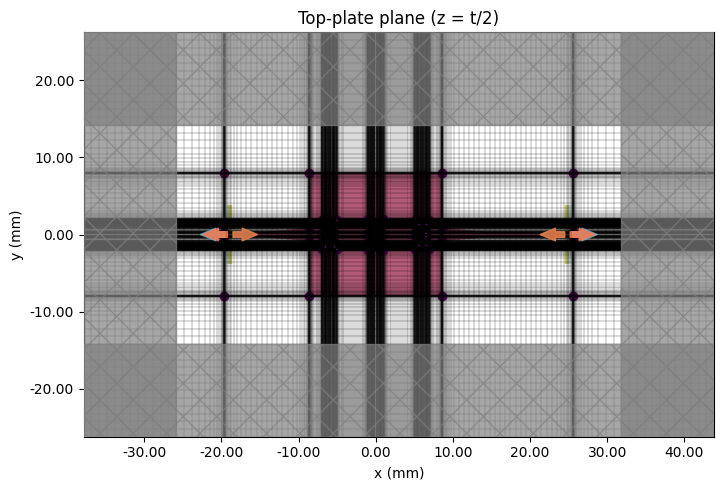

In [18]:
fig, axes = plt.subplots(figsize=(8, 5), tight_layout=True)
tcm.plot_sim(z=t_metal / 2, ax=axes)
tcm.simulation.plot_grid(z=t_metal / 2, ax=axes)
axes.set_title("Top-plate plane (z = t/2)")

## Run Simulation

In [ ]:
tcm_data = web.run(
    tcm,
    task_name="SIW CSRR three-cell filter",
    path="data/siw_csrr_3cell.hdf5",
    verbose=False,
)

In [21]:
smat = tcm_data.smatrix()

## Results

S-parameters for the three-CSRR filter. The SIW TE₁₀ cutoff defines the high-pass edge, which can be estimated using Eq. 1 in [1]:
$$a_\text{eqv} = a - \frac{d^2}{0.95\, b}, \qquad f_c = \frac{c}{2\sqrt{\varepsilon_r}\, a_\text{eqv}}.$$

The three CSRRs have transmission zeros above the high-pass edge, and thus define the low-pass edge.

a_eqv    = 13.579 mm
f_cutoff = 7.41 GHz


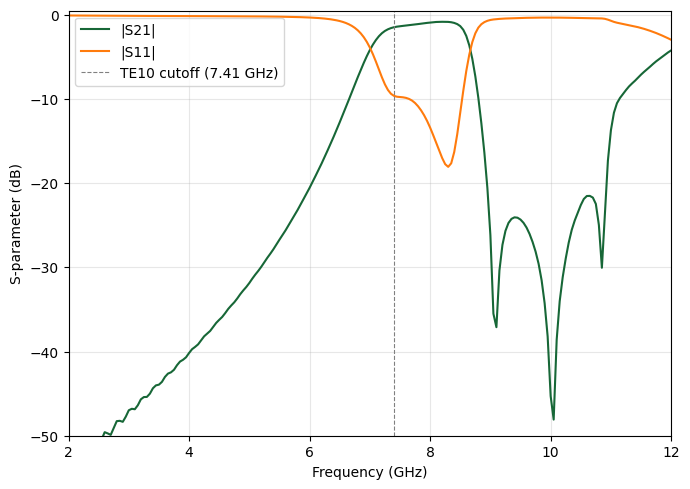

In [22]:
# TE10 cutoff from the paper's equivalent-width formula [1, eq. 1].
# a_eqv corrects the via-row separation for finite via size/pitch;
# f_cutoff is the rectangular-waveguide TE10 cutoff evaluated at a_eqv.
a_eqv = a_siw - via_d**2 / (0.95 * via_pitch)
f_cutoff = td.C_0 / (2 * np.sqrt(eps_sub) * a_eqv)
print(f"a_eqv    = {a_eqv / 1000:.3f} mm")
print(f"f_cutoff = {f_cutoff / 1e9:.2f} GHz")


def sparam(smat, i, j):
    return np.conjugate(smat.data.isel(port_out=i - 1, port_in=j - 1))


def sparam_dB(smat, i, j):
    return 20 * np.log10(np.abs(sparam(smat, i, j)))


fig, ax = plt.subplots(figsize=(7, 5), tight_layout=True)
ax.plot(freqs / 1e9, sparam_dB(smat, 2, 1), label="|S21|")
ax.plot(freqs / 1e9, sparam_dB(smat, 1, 1), label="|S11|")
ax.axvline(
    f_cutoff / 1e9, color="gray", ls="--", lw=0.8, label=f"TE10 cutoff ({f_cutoff / 1e9:.2f} GHz)"
)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("S-parameter (dB)")
ax.set_ylim(-50, 0.5)
ax.set_xlim(f_min / 1e9, f_max / 1e9)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Field Visualization

Total |E| on the mid-substrate plane at three sampling frequencies: one below the SIW
TE₁₀ cutoff (evanescent), one in the pass-band (TE₁₀ propagating), one in the upper
stop-band (CSRR trapping energy). Each panel is normalized to its own peak. 

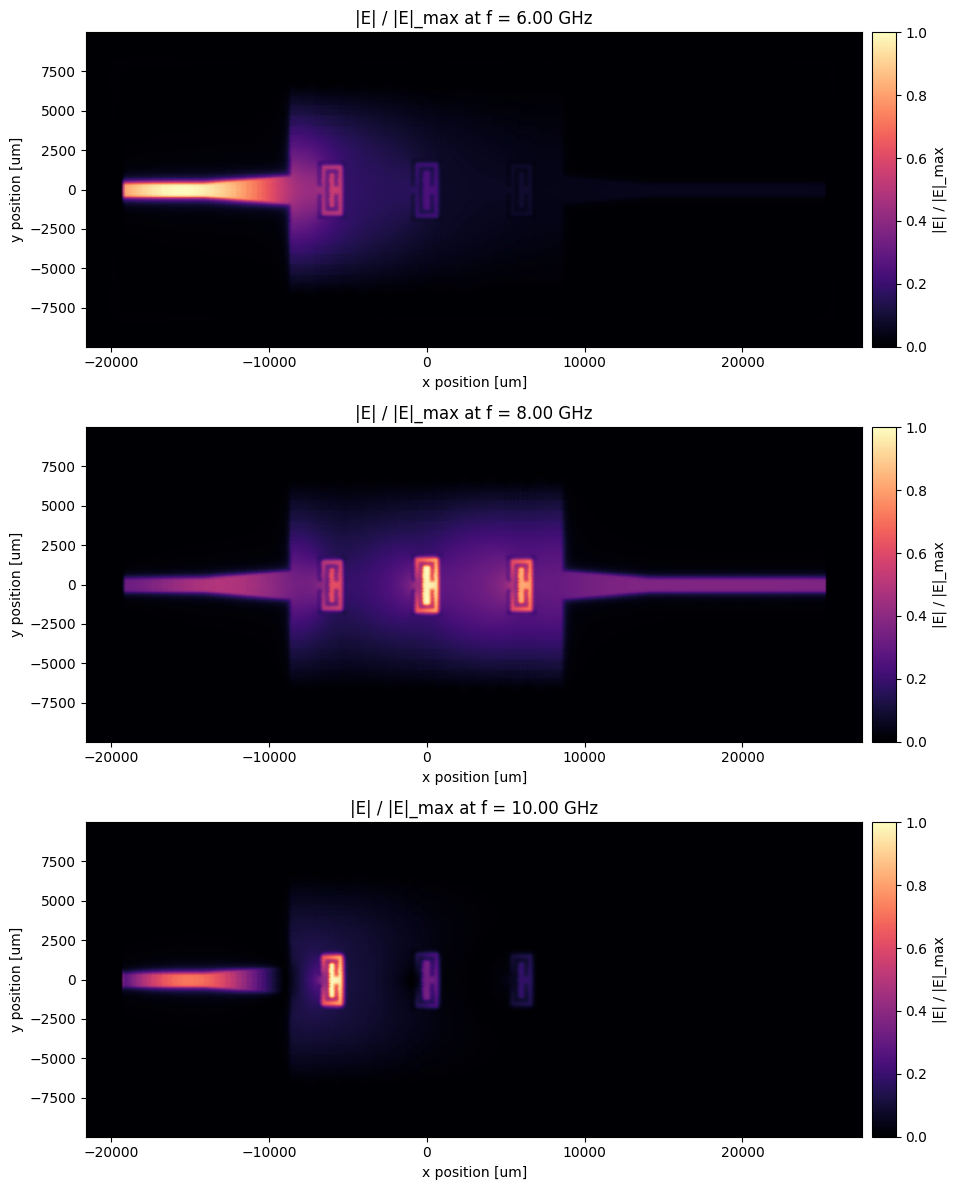

In [23]:
# Three target frequencies snapped to the nearest field-monitor samples.
freqs_plot = [6e9, 8e9, 10e9]


def snap(f):
    return field_freqs[np.argmin(np.abs(field_freqs - f))]


# Wave-port field data is indexed as "<port>@<mode index>" (multi-mode-safe key).
sim_data = tcm_data.data["WP1@0"]
fd = sim_data[field_mon_top.name]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), tight_layout=True)
for ax, f_target in zip(axes, freqs_plot):
    f_near = snap(f_target)
    E2 = (
        np.abs(fd.Ex.sel(f=f_near)) ** 2
        + np.abs(fd.Ey.sel(f=f_near)) ** 2
        + np.abs(fd.Ez.sel(f=f_near)) ** 2
    )
    E_abs = np.sqrt(E2).squeeze()
    E_norm = E_abs / float(E_abs.max())
    im = E_norm.plot(
        ax=ax,
        x="x",
        y="y",
        vmin=0,
        vmax=1,
        cmap="magma",
        add_colorbar=False,
        shading="gouraud",
        infer_intervals=False,
    )
    ax.set_title(f"|E| / |E|_max at f = {f_near / 1e9:.2f} GHz")
    ax.set_aspect("equal")
    # Crop to the PCB footprint; don't show the air padding around the device.
    ax.set_xlim(x_ms_L - 2000, x_ms_R + 2000)
    ax.set_ylim(-plate_half_y - 2000, plate_half_y + 2000)
    # Colorbar matched to plot height via an axes divider.
    cax = make_axes_locatable(ax).append_axes("right", size="3%", pad=0.1)
    fig.colorbar(im, cax=cax, label="|E| / |E|_max")
plt.show()

## Conclusion

Three CSRRs etched into an SIW broadwall give a compact band-pass: SIW cutoff sets the
high-pass edge, three CSRR resonances clustered just above cutoff set the low-pass edge.
Scaling `c, d` cell-to-cell widens or narrows the upper stop-band.

## References

[1] X.-C. Zhang, Z.-Y. Yu, and J. Xu, "Novel Band-pass Substrate Integrated Waveguide (SIW)
Filter Based on Complementary Split Ring Resonators (CSRRs)," *Progress In Electromagnetics
Research*, PIER 72, 39–46, 2007.